# 05 · Perfis territoriais: quais municípios se parecem

A terceira pergunta estratégica é sobre semelhança: quais regiões possuem padrões parecidos? A resposta útil para política pública é de perfil, mais do que geográfica: grupos de municípios que compartilham o mesmo conjunto de condições (fluxo escolar, docentes, porte, nível socioeconômico, histórico), porque para esses grupos faz sentido desenhar a mesma intervenção.

É um problema não supervisionado. O caminho segue o que as aulas cobrem: preparação geométrica (imputação e padronização, porque K-Means usa distância euclidiana), escolha de K pelo método do cotovelo e pela silhueta, K-Means como método principal, agrupamento hierárquico como contraste e PCA para visualizar e interpretar. Os perfis são cruzados com o risco projetado para 2026 do notebook 04, o que transforma o agrupamento em uma matriz de priorização.

In [1]:
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer

from src.visualization.estilo import aplicar_estilo, salvar, fmt_pct, AZUL, LARANJA, CINZA, VERDE, VERMELHO, PALETA, CORES_REGIAO
from src.visualization.rotulos import rotulo, rotular

aplicar_estilo()
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
SEED = 42

## 1. Retrato mais recente de cada município

Uma linha por município, com o contexto mais recente disponível (a linha de 2026 da ABT: indicador de 2025, Censo Escolar 2025, rendimento 2024, IDEB 2025, Censo 2022, INSE 2023). As variáveis escolhidas descrevem condições, não resultados futuros; o risco entra só no cruzamento final.

In [2]:
abt = pd.read_parquet("data/processed/abt_municipio.parquet")
base = abt[abt["ano_alvo"] == 2026].copy()

variaveis = [
    "indicador_t1", "participacao_t1",
    "distorcao_ai_pct", "reprovacao_ai_pct", "abandono_ai_pct",
    "afd_ai_grupo1_pct", "docentes_superior_ai_pct", "alunos_por_turma_2ano",
    "ideb_ultimo", "ideb_tendencia",
    "inse_medio", "pct_alunos_rural", "populacao", "pib_per_capita", "pct_vab_agro",
]
log_vars = ["populacao", "pib_per_capita"]
x = base[variaveis].copy()
for v in log_vars:
    x[v] = np.log1p(x[v])
prep = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
z = prep.fit_transform(x)
print(z.shape, "municípios x variáveis;", f"nulos imputados: {int(x.isna().sum().sum())}")
pd.Series(rotular(variaveis)).to_frame("variáveis do perfil")

(5523, 15) municípios x variáveis; nulos imputados: 258


,variáveis do perfil
0,% alfabetizados no ano anterior
1,Participação na prova no ano anterior (%)
2,"Distorção idade-série, anos iniciais (%)"
3,"Taxa de reprovação, anos iniciais (%)"
4,"Taxa de abandono, anos iniciais (%)"
5,"Docentes com formação adequada, anos iniciais (%)"
6,"Docentes com curso superior, anos iniciais (%)"
7,Alunos por turma no 2o ano
8,IDEB anos iniciais (última edição)
9,Tendência do IDEB (pontos por edição)


## 2. Quantos grupos: cotovelo e silhueta

O K-Means minimiza a soma dos quadrados intra-grupo (WCSS). O cotovelo procura o K a partir do qual o ganho marginal cai; a silhueta mede coesão contra separação (quanto maior, melhor); o índice de Davies-Bouldin mede dispersão contra separação (quanto menor, melhor). Os três juntos evitam escolher K só pelo olho.

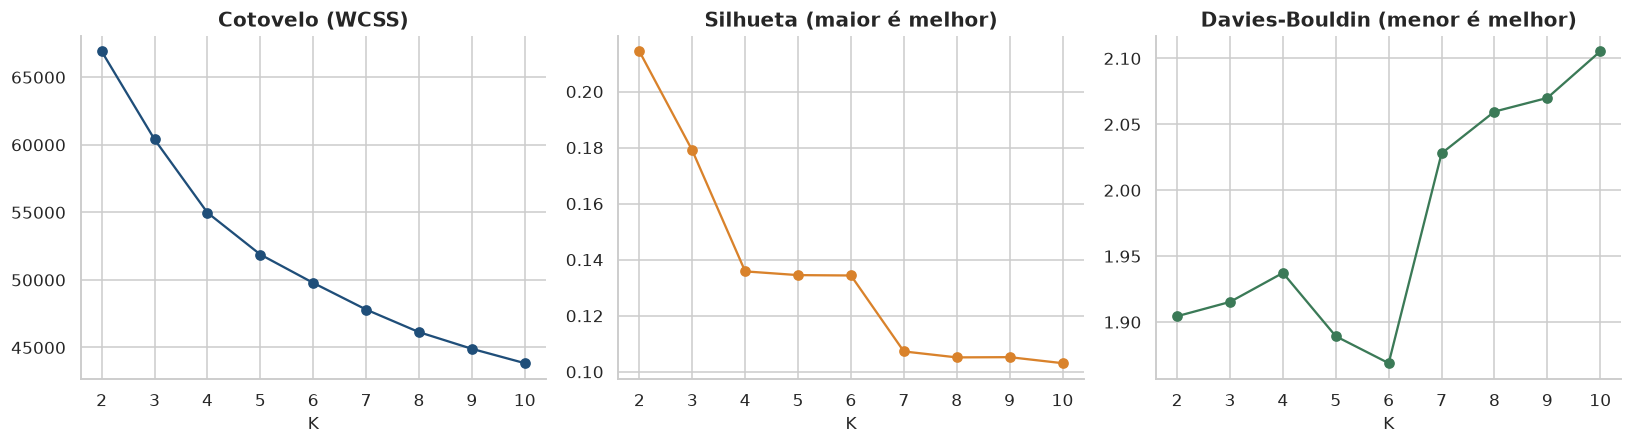

,k,wcss,silhueta,davies_bouldin
0,2,66910.804,0.214,1.904
1,3,60393.553,0.179,1.915
2,4,54972.225,0.136,1.937
3,5,51877.209,0.134,1.889
4,6,49777.982,0.134,1.869
5,7,47805.159,0.107,2.028
6,8,46133.600,0.105,2.060
7,9,44899.960,0.105,2.070
8,10,43837.448,0.103,2.105


In [3]:
ks = range(2, 11)
avaliacao = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(z)
    avaliacao.append({"k": k, "wcss": km.inertia_, "silhueta": silhouette_score(z, km.labels_, sample_size=3000, random_state=SEED), "davies_bouldin": davies_bouldin_score(z, km.labels_)})
avaliacao = pd.DataFrame(avaliacao)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].plot(avaliacao["k"], avaliacao["wcss"], marker="o", color=AZUL)
axes[0].set_title("Cotovelo (WCSS)")
axes[1].plot(avaliacao["k"], avaliacao["silhueta"], marker="o", color=LARANJA)
axes[1].set_title("Silhueta (maior é melhor)")
axes[2].plot(avaliacao["k"], avaliacao["davies_bouldin"], marker="o", color=VERDE)
axes[2].set_title("Davies-Bouldin (menor é melhor)")
for ax in axes:
    ax.set_xlabel("K")
salvar(fig, "05_escolha_k")
plt.show()
avaliacao.round(3)

In [4]:
K = 4
km = KMeans(n_clusters=K, n_init=20, random_state=SEED).fit(z)
base["cluster"] = km.labels_
print("tamanho dos grupos:", base["cluster"].value_counts().sort_index().to_dict())

tamanho dos grupos: {0: 838, 1: 2001, 2: 1386, 3: 1298}


A silhueta é modesta em todos os K (é o comum em dados socioeducacionais, que formam um contínuo e não ilhas), e o cotovelo é suave. Entre K = 3 e K = 5 a silhueta e o Davies-Bouldin praticamente empatam; K = 4 é a escolha com perfis distintos e interpretáveis, e com grupos grandes o bastante para orientar política. Dois grupos seriam só "melhor" e "pior"; seis começam a separar por porte, sem mudar a leitura.

## 3. Contraste com o agrupamento hierárquico

O hierárquico aglomerativo (ligação de Ward, a mesma função objetivo do K-Means) não precisa de K a priori e mostra a estrutura no dendrograma. Serve para conferir se os quatro grupos do K-Means são estáveis ou um artefato do algoritmo.

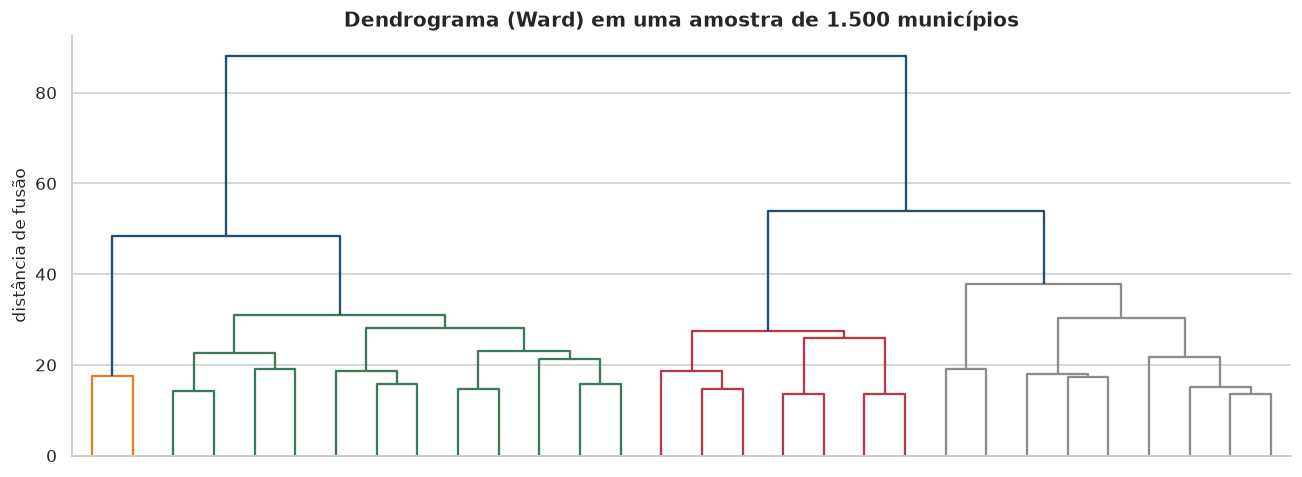

concordância K-Means x hierárquico (índice de Rand ajustado): 0.50


Hierárquico,0,1,2,3
K-Means,,,,
0,187,34,595,22
1,116,1786,10,89
2,1237,67,79,3
3,147,518,8,625


In [5]:
rng = np.random.default_rng(SEED)
idx = rng.choice(len(z), 1500, replace=False)
lk = linkage(z[idx], method="ward")
fig, ax = plt.subplots(figsize=(12, 4.5))
dendrogram(lk, truncate_mode="lastp", p=30, ax=ax, color_threshold=lk[-3, 2], no_labels=True)
ax.set_title("Dendrograma (Ward) em uma amostra de 1.500 municípios")
ax.set_ylabel("distância de fusão")
salvar(fig, "05_dendrograma")
plt.show()

agg = AgglomerativeClustering(n_clusters=K, linkage="ward").fit(z)
print(f"concordância K-Means x hierárquico (índice de Rand ajustado): {adjusted_rand_score(km.labels_, agg.labels_):.2f}")
pd.crosstab(base["cluster"], agg.labels_, rownames=["K-Means"], colnames=["Hierárquico"])

A concordância é moderada (Rand ajustado de 0,50), o que é coerente com a silhueta baixa: as fronteiras entre perfis vizinhos são difusas. Mas a tabela cruzada mostra que três dos quatro grupos são estáveis entre os métodos (o de fluxo comprometido, o de pequenos de baixa renda e o de redes consolidadas); só o grupo urbano se divide no hierárquico. Os perfis não são um acaso do K-Means.

### 3.1 Contraste com modelos de mistura e com densidade

Dois outros métodos das aulas, com pressupostos diferentes do K-Means: a mistura de gaussianas (GMM), que admite grupos elípticos de tamanhos diferentes e é escolhida pelo BIC, e o DBSCAN, que define grupos por densidade e não exige K.

GMM: menor BIC em K = 8; com K = 4, concordância com o K-Means (Rand ajustado) = 0.24


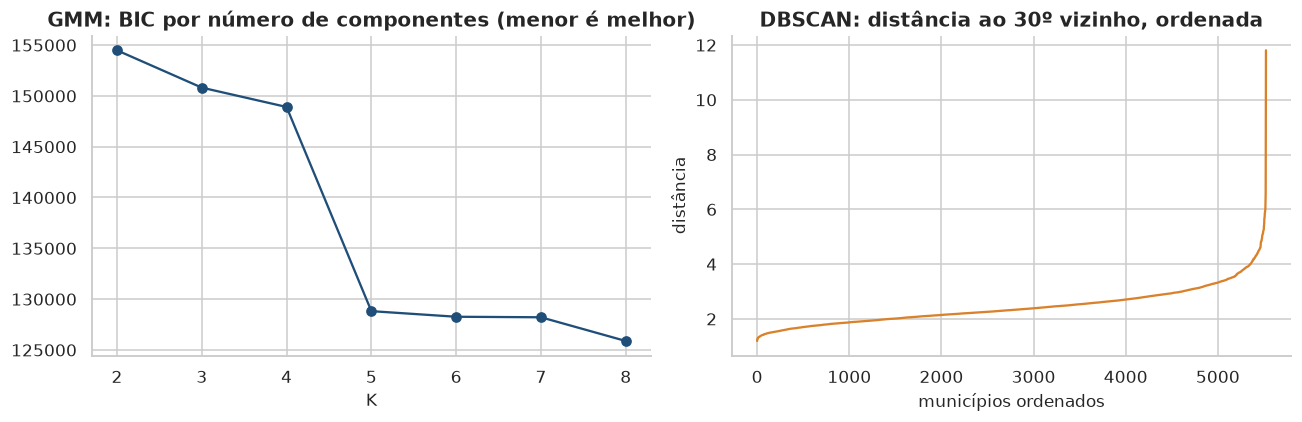

,eps,grupos,ruído (%)
0,2.5,1,14.1
1,3.0,1,4.3
2,3.5,1,1.4
3,4.0,1,0.5


In [6]:
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors

bics = []
for k in range(2, 9):
    gmm = GaussianMixture(n_components=k, covariance_type="full", n_init=3, random_state=SEED).fit(z)
    bics.append({"k": k, "bic": gmm.bic(z)})
bics = pd.DataFrame(bics)
k_gmm = int(bics.sort_values("bic").iloc[0]["k"])
gmm = GaussianMixture(n_components=K, covariance_type="full", n_init=3, random_state=SEED).fit(z)
rot_gmm = gmm.predict(z)
print(f"GMM: menor BIC em K = {k_gmm}; com K = {K}, concordância com o K-Means (Rand ajustado) = {adjusted_rand_score(km.labels_, rot_gmm):.2f}")

# DBSCAN: eps pelo grafico da k-distancia (minPts = 2 x dimensoes = 30)
min_pts = 2 * z.shape[1]
dist_k = np.sort(NearestNeighbors(n_neighbors=min_pts).fit(z).kneighbors(z)[0][:, -1])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(bics["k"], bics["bic"], marker="o", color=AZUL)
axes[0].set_title("GMM: BIC por número de componentes (menor é melhor)")
axes[0].set_xlabel("K")
axes[1].plot(dist_k, color=LARANJA)
axes[1].set_title(f"DBSCAN: distância ao {min_pts}º vizinho, ordenada")
axes[1].set_xlabel("municípios ordenados")
axes[1].set_ylabel("distância")
salvar(fig, "05_gmm_dbscan")
plt.show()

resultados_db = []
for eps in (2.5, 3.0, 3.5, 4.0):
    db = DBSCAN(eps=eps, min_samples=min_pts).fit(z)
    n_grupos = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    resultados_db.append({"eps": eps, "grupos": n_grupos, "ruído (%)": round(100 * (db.labels_ == -1).mean(), 1)})
pd.DataFrame(resultados_db)

O BIC do GMM continua caindo conforme K cresce, sem um mínimo claro em K pequeno, o que é típico de dados contínuos sem grupos compactos; com K = 4 a partição do GMM concorda em parte com a do K-Means. O DBSCAN, para qualquer eps razoável pelo gráfico da k-distância, encontra um único grupo, com uma fração de ruído que cai de 14% para menos de 1% conforme eps cresce: não há regiões de densidade separadas por vazios. Os dois resultados apontam na mesma direção da silhueta baixa: os municípios formam um contínuo, e os quatro perfis do K-Means são um recorte útil desse contínuo, não fronteiras naturais.

## 4. PCA: o que separa os grupos

O PCA reduz as 15 variáveis a componentes ortogonais. Os dois primeiros bastam para visualizar; as cargas (loadings) dizem o que cada eixo significa.

variância explicada pelos 2 primeiros componentes: 43% | componentes para 80%: 7


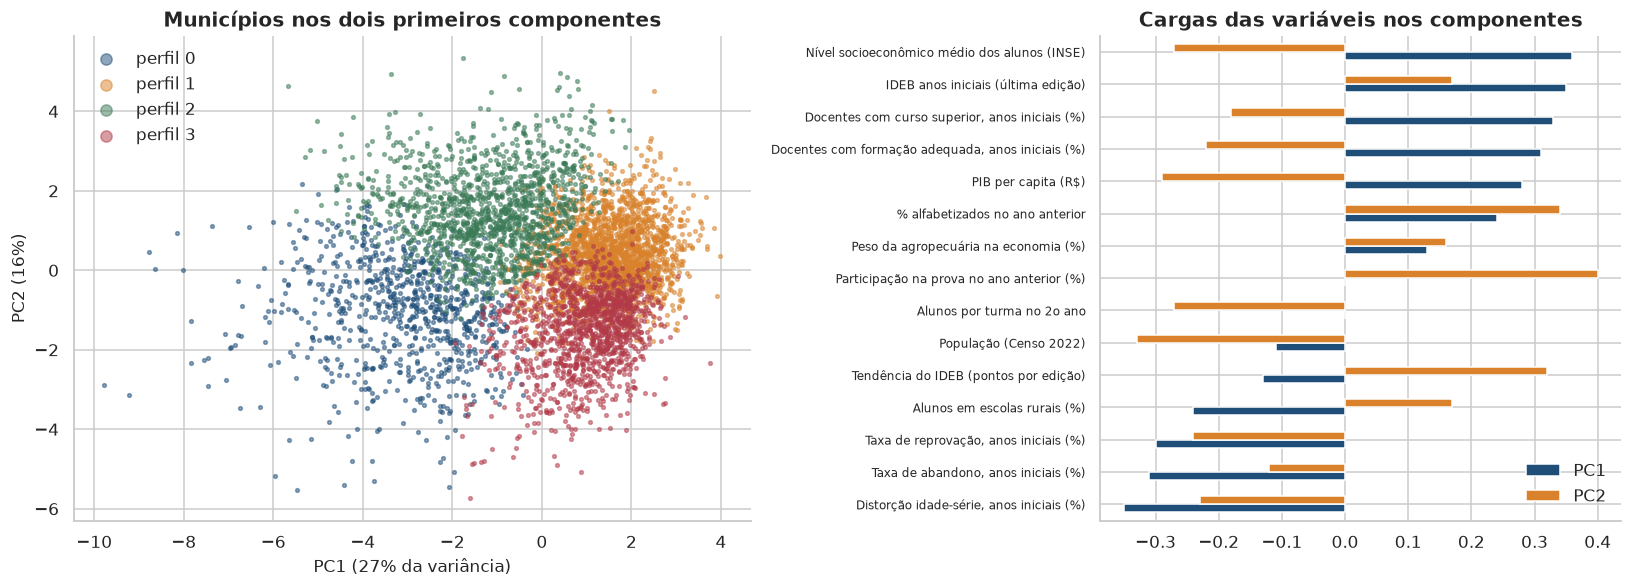

In [7]:
pca = PCA(random_state=SEED).fit(z)
var_acum = np.cumsum(pca.explained_variance_ratio_)
print("variância explicada pelos 2 primeiros componentes:", f"{100 * var_acum[1]:.0f}%", "| componentes para 80%:", int(np.argmax(var_acum >= 0.8) + 1))
comp = pca.transform(z)[:, :2]
cargas = pd.DataFrame(pca.components_[:2].T, index=rotular(variaveis), columns=["PC1", "PC2"]).round(2)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [1.3, 1]})
for c in range(K):
    m = base["cluster"].values == c
    axes[0].scatter(comp[m, 0], comp[m, 1], s=6, alpha=0.5, color=PALETA[c], label=f"perfil {c}")
axes[0].set_xlabel(f"PC1 ({100 * pca.explained_variance_ratio_[0]:.0f}% da variância)")
axes[0].set_ylabel(f"PC2 ({100 * pca.explained_variance_ratio_[1]:.0f}%)")
axes[0].set_title("Municípios nos dois primeiros componentes")
axes[0].legend(markerscale=3)
cargas.sort_values("PC1").plot.barh(ax=axes[1], color=[AZUL, LARANJA])
axes[1].set_title("Cargas das variáveis nos componentes")
axes[1].tick_params(axis="y", labelsize=8)
salvar(fig, "05_pca")
plt.show()

O primeiro componente é um eixo de **fluxo e resultado**: distorção, reprovação e abandono de um lado; indicador, IDEB e docentes qualificados do outro. O segundo é um eixo de **porte e renda**: população, PIB per capita e INSE contra ruralidade e peso da agropecuária. Os perfis se distribuem ao longo desses dois eixos, e é isso que os nomes abaixo capturam.

## 5. Os perfis

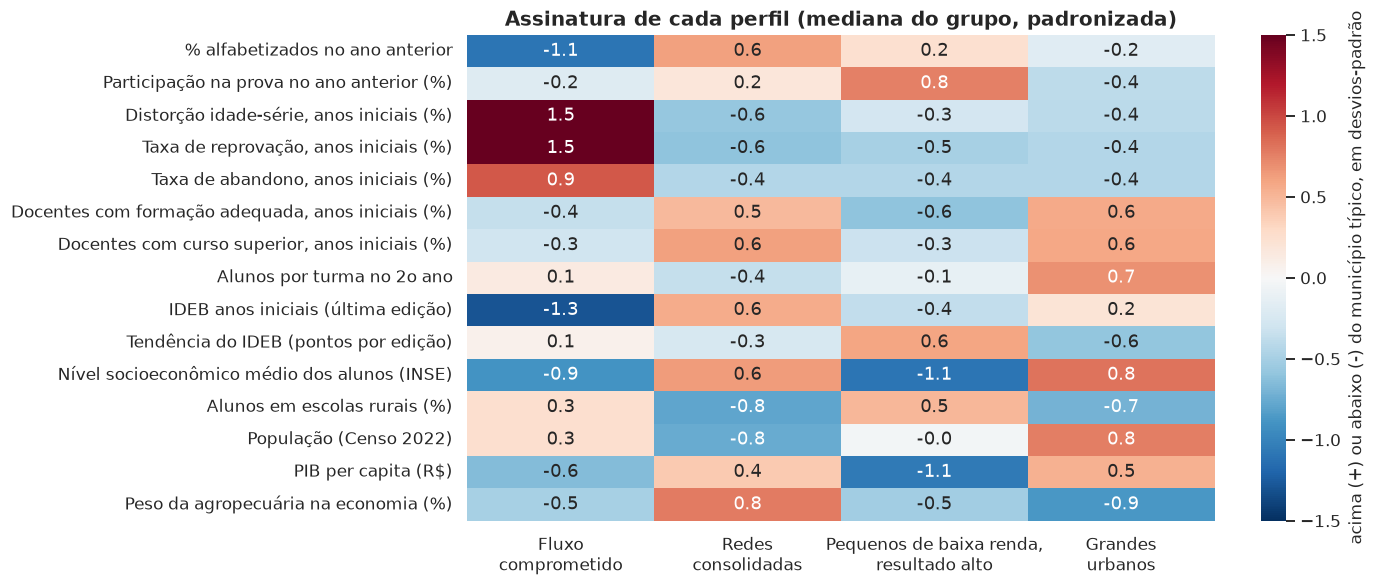

cluster,0,1,2,3
municípios,838.0,2001.0,1386.0,1298.0
% alfabetizados no ano anterior,54.2,81.9,75.7,68.8
Participação na prova no ano anterior (%),92.0,94.0,97.0,91.0
"Distorção idade-série, anos iniciais (%)",14.0,2.9,4.5,3.8
"Taxa de reprovação, anos iniciais (%)",7.0,0.7,1.0,1.2
"Taxa de abandono, anos iniciais (%)",0.6,0.0,0.0,0.0
"Docentes com formação adequada, anos iniciais (%)",69.0,83.3,65.1,84.6
"Docentes com curso superior, anos iniciais (%)",85.6,98.0,85.4,97.4
Alunos por turma no 2o ano,19.3,17.4,18.3,21.4
IDEB anos iniciais (última edição),5.1,6.7,5.9,6.4


In [8]:
perfil = base.groupby("cluster")[variaveis].median()
perfil_z = pd.DataFrame(prep.transform(perfil.assign(**{v: np.log1p(perfil[v]) for v in log_vars})), index=perfil.index, columns=rotular(variaveis))

# nomes dos perfis a partir da assinatura: ordenados pelo indicador mediano
ordem = perfil["indicador_t1"].sort_values().index.tolist()
nomes_perfis, nomes_curtos = {}, {}
for posicao, c in enumerate(ordem):
    p = perfil.loc[c]
    if posicao == 0:
        nomes_perfis[c] = "Fluxo comprometido: distorção e reprovação altas, resultado baixo"
        nomes_curtos[c] = "Fluxo\ncomprometido"
    elif posicao == len(ordem) - 1:
        nomes_perfis[c] = "Redes consolidadas: resultado alto e fluxo regular"
        nomes_curtos[c] = "Redes\nconsolidadas"
    elif p["populacao"] >= perfil["populacao"].median():
        nomes_perfis[c] = "Grandes urbanos: porte e renda altos, resultado intermediário"
        nomes_curtos[c] = "Grandes\nurbanos"
    else:
        nomes_perfis[c] = "Pequenos de baixa renda com resultado alto"
        nomes_curtos[c] = "Pequenos de baixa renda,\nresultado alto"

fig, ax = plt.subplots(figsize=(13, 5.5))
sns.heatmap(perfil_z.T, cmap="RdBu_r", center=0, vmin=-1.5, vmax=1.5, annot=True, fmt=".1f", ax=ax, cbar_kws={"label": "acima (+) ou abaixo (-) do município típico, em desvios-padrão"})
ax.set_xticklabels([nomes_curtos[c] for c in perfil_z.index], rotation=0)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Assinatura de cada perfil (mediana do grupo, padronizada)")
salvar(fig, "05_assinatura_perfis")
plt.show()

resumo = perfil.copy()
resumo.insert(0, "municipios", base["cluster"].value_counts().sort_index())
resumo.columns = ["municípios"] + rotular(variaveis)
resumo.round(1).T

In [9]:
base["perfil"] = base["cluster"].map(nomes_perfis)
composicao = pd.crosstab(base["perfil"], base["nome_regiao"], normalize="index").mul(100).round(0)
composicao["municípios"] = base["perfil"].value_counts()
composicao

nome_regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul,municípios
perfil,,,,,,
"Fluxo comprometido: distorção e reprovação altas, resultado baixo",4.0,60.0,23.0,9.0,4.0,838
"Grandes urbanos: porte e renda altos, resultado intermediário",8.0,8.0,4.0,53.0,26.0,1298
Pequenos de baixa renda com resultado alto,1.0,82.0,7.0,9.0,1.0,1386
Redes consolidadas: resultado alto e fluxo regular,15.0,3.0,5.0,37.0,40.0,2001


A composição regional responde à pergunta do desafio: **os perfis cortam as regiões**. O perfil de fluxo comprometido é majoritariamente nordestino e nortista, mas tem municípios do Sudeste e do Sul. O achado mais interessante é o perfil dos pequenos de baixa renda com resultado alto: 82% nordestino (Ceará, Piauí, Paraíba, Pernambuco), com INSE tão baixo quanto o do perfil de fluxo comprometido e resultado 20 pontos maior. Ou seja, "região semelhante" para política pública é o perfil, não a macrorregião.

## 6. Perfil x risco: a matriz de priorização

O risco projetado para 2026 (notebook 04) cruzado com o perfil diz onde o esforço rende mais: um município de fluxo comprometido em risco pede intervenção estrutural; um de rede consolidada em risco provavelmente tem uma meta agressiva e precisa de acompanhamento, não de reforma.

In [10]:
risco = pd.read_csv("reports/municipios_risco_2026.csv")[["id_municipio", "risco_2026", "nivel_previsto_2026", "meta_2026"]]
base = base.merge(risco, on="id_municipio", how="left")
matriz = base.groupby("perfil").agg(
    municipios=("id_municipio", "size"),
    risco_medio=("risco_2026", "mean"),
    em_risco=("risco_2026", lambda s: (s >= 0.5).mean()),
    indicador_2025=("indicador_t1", "median"),
    meta_2026=("meta_2026", "median"),
).sort_values("risco_medio", ascending=False)
matriz["em_risco"] = (100 * matriz["em_risco"]).round(0)
matriz.round(2)

,municipios,risco_medio,em_risco,indicador_2025,meta_2026
perfil,,,,,
"Grandes urbanos: porte e renda altos, resultado intermediário",1298,0.39,32.0,68.85,69.71
"Fluxo comprometido: distorção e reprovação altas, resultado baixo",838,0.31,22.0,54.19,58.41
Redes consolidadas: resultado alto e fluxo regular,2001,0.24,15.0,81.88,75.46
Pequenos de baixa renda com resultado alto,1386,0.15,5.0,75.72,67.74


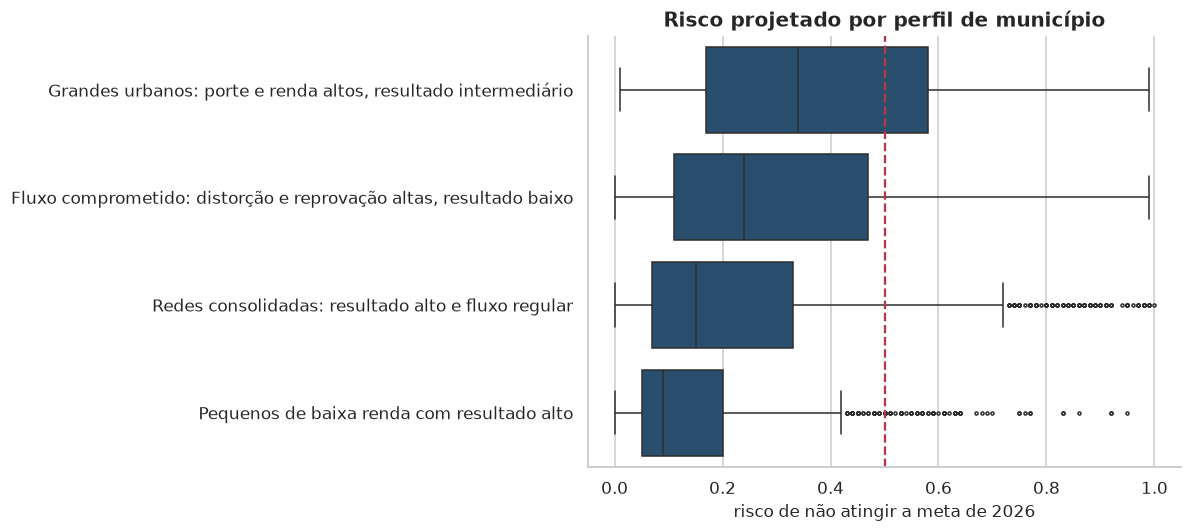

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
ordem_perfis = matriz.index.tolist()
sns.boxplot(data=base, y="perfil", x="risco_2026", order=ordem_perfis, ax=ax, color=AZUL, fliersize=2)
ax.axvline(0.5, color=VERMELHO, ls="--")
ax.set_xlabel("risco de não atingir a meta de 2026")
ax.set_ylabel("")
ax.set_title("Risco projetado por perfil de município")
salvar(fig, "05_perfil_x_risco")
plt.show()

In [12]:
saida = base[["id_municipio", "nome_municipio", "sigla_uf", "nome_regiao", "cluster", "perfil", "risco_2026"]].sort_values(["perfil", "risco_2026"], ascending=[True, False])
saida.to_csv("reports/perfis_municipios.csv", index=False)
saida.groupby(["perfil", "sigla_uf"]).size().unstack(fill_value=0).T.head(27)

perfil,"Fluxo comprometido: distorção e reprovação altas, resultado baixo","Grandes urbanos: porte e renda altos, resultado intermediário",Pequenos de baixa renda com resultado alto,Redes consolidadas: resultado alto e fluxo regular
sigla_uf,,,,
AC,14,6,2,0
AL,1,5,84,12
AM,42,1,19,0
AP,15,1,0,0
BA,214,17,180,6
CE,0,20,162,2
ES,0,33,2,43
GO,1,57,13,175
MA,36,5,174,2


## 7. O que fica registrado

- **Quatro perfis** com assinaturas claras em dois eixos (fluxo e resultado; porte e renda), escolhidos por cotovelo, silhueta e Davies-Bouldin; três deles estáveis também no hierárquico de Ward. GMM e DBSCAN confirmam que os dados formam um contínuo, sem grupos de densidade separados.
- **Perfis cortam regiões**: a semelhança útil para política é de condições, não de geografia; o perfil nordestino de baixa renda e resultado alto mostra que a gestão da rede pesa mais do que o contexto socioeconômico.
- **Matriz perfil x risco** em `reports/perfis_municipios.csv`, que separa risco por falta de estrutura de risco por meta agressiva.
- **Limitação**: a silhueta baixa lembra que os municípios formam um contínuo; os perfis são um recorte útil, não fronteiras naturais.